# Lab04: Đánh giá hiệu suất các kỹ thuật Feature Selection
**Dataset:** House Price Prediction (Ames Housing, Kaggle) · **Mô hình:** SVR (SVM hồi quy), RandomForest, XGBoost

**Quy trình**
1. Dữ liệu đã tiền xử lý ở `01_preprocessing.ipynb` (265 feature sau one-hot, target `log_SalePrice = log1p(SalePrice)`).
2. Baseline 3 mô hình trên toàn bộ 265 feature (`02_baseline_modeling.ipynb`).
3. **Notebook này:** áp dụng Filter, Wrapper, Embedded; mọi bộ chọn feature nằm *trong* `Pipeline` nên được fit lại ở từng fold CV (không leakage).
4. So sánh công bằng: giữ nguyên siêu tham số baseline, cùng `random_state=42`, 5-fold CV trên train; **tập test chỉ dùng để báo cáo, không dùng để chọn feature/model**.

| Nhóm | Kỹ thuật (`technique`) | Cách hoạt động |
|---|---|---|
| Filter | `filter_kbest` | `SelectKBest` + F-test (`f_regression`) |
| Filter | `filter_mi` | `SelectKBest` + Mutual Information |
| Wrapper | `wrapper_rfe` | Recursive Feature Elimination (bỏ dần 20 feature/lượt) |
| Embedded | `embedded_lasso` | `SelectFromModel` + `LassoCV` (giữ feature có hệ số ≠ 0) |
| Embedded | `embedded_rf` | `SelectFromModel` + độ quan trọng RandomForest (top-k) |

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data/processed/X_train.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluate import evaluate_model
from src.feature_selection import TECHNIQUES, make_models, make_pipeline

DATA_DIR = PROJECT_ROOT / 'data/processed'
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE, N_SPLITS, K = 42, 5, 50   # K: số feature giữ lại (filter / RFE / embedded_rf)

X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze('columns')
feature_names = pd.read_csv(DATA_DIR / 'feature_names.csv')['feature'].tolist()

assert list(X_train.columns) == feature_names == list(X_test.columns)
print('Train:', X_train.shape, '| Test:', X_test.shape, '| K =', K)

Train: (1166, 265) | Test: (292, 265) | K = 50


## 1. Baseline (265 feature)
Đọc lại kết quả từ `02_baseline_modeling.ipynb` để làm mốc so sánh.

In [2]:
baseline = pd.read_csv(DATA_DIR / 'baseline_results.csv')
baseline[['technique','model','cv_log_rmse','test_log_rmse','test_original_rmse','test_original_r2','n_features','cv_seconds']].round(4)

,technique,model,cv_log_rmse,test_log_rmse,test_original_rmse,test_original_r2,n_features,cv_seconds
0,baseline,XGBoost,0.1161,0.1167,18836.1615,0.9358,265,3.3097
1,baseline,RandomForest,0.1330,0.1416,23085.8974,0.9035,265,3.7976
2,baseline,SVR,0.1389,0.1419,22065.4098,0.9119,265,0.6510


## 2. Chạy Feature Selection × mô hình
Mỗi tổ hợp = `Pipeline([selector, model])`, đánh giá bằng `evaluate_model` (5-fold CV trên train + đánh giá cuối trên test).
`embedded_lasso` tự quyết định số feature (hệ số khác 0) nên `n_features` có thể khác `K`.

In [3]:
import time
rows, fitted = [], {}
t0 = time.time()
for technique in TECHNIQUES:
    for name, model in make_models().items():
        pipe = make_pipeline(technique, name, model, k=K)
        res = evaluate_model(technique, name, pipe, X_train, y_train, X_test, y_test, N_SPLITS, RANDOM_STATE)
        fitted[(technique, name)] = res.pop('_fitted_model')
        rows.append(res)
        print(f"{technique:15s} {name:13s} CV logRMSE={res['cv_log_rmse']:.4f}  "
              f"n_feat={res['n_features']:3d}  ({time.time()-t0:.0f}s)")

fs_results = pd.DataFrame(rows)
all_results = pd.concat([baseline, fs_results], ignore_index=True)
all_results.to_csv(DATA_DIR / 'feature_selection_results.csv', index=False)
print('Đã lưu data/processed/feature_selection_results.csv')

filter_kbest    SVR           CV logRMSE=0.1501  n_feat= 50  (1s)


filter_kbest    RandomForest  CV logRMSE=0.1376  n_feat= 50  (19s)


filter_kbest    XGBoost       CV logRMSE=0.1307  n_feat= 50  (20s)


filter_mi       SVR           CV logRMSE=0.1478  n_feat= 50  (28s)


filter_mi       RandomForest  CV logRMSE=0.1334  n_feat= 50  (55s)


...

embedded_lasso  RandomForest  CV logRMSE=0.1316  n_feat= 93  (147s)


embedded_lasso  XGBoost       CV logRMSE=0.1173  n_feat= 93  (151s)


embedded_rf     SVR           CV logRMSE=0.1432  n_feat= 50  (163s)


embedded_rf     RandomForest  CV logRMSE=0.1332  n_feat= 50  (194s)


embedded_rf     XGBoost       CV logRMSE=0.1221  n_feat= 50  (207s)
Đã lưu data/processed/feature_selection_results.csv


## 3. Bảng kết quả tổng hợp

In [4]:
cols = ['technique','model','n_features','cv_log_rmse','cv_log_r2','test_log_rmse','test_original_rmse',
        'test_original_mae','test_original_r2','cv_seconds','train_seconds']
display(all_results[cols].sort_values(['model','cv_log_rmse']).round(4).reset_index(drop=True))

,technique,model,n_features,cv_log_rmse,cv_log_r2,test_log_rmse,test_original_rmse,test_original_mae,test_original_r2,cv_seconds,train_seconds
0,embedded_lasso,RandomForest,93,0.1316,0.8891,0.1419,22949.9843,16139.4311,0.9046,20.8343,4.8285
1,wrapper_rfe,RandomForest,50,0.1330,0.8868,0.1430,22955.5488,15821.8898,0.9046,33.4417,8.1160
2,baseline,RandomForest,265,0.1330,0.8868,0.1416,23085.8974,16157.5014,0.9035,3.7976,0.8036
3,embedded_rf,RandomForest,50,0.1332,0.8865,0.1423,22605.0623,15757.3413,0.9075,24.8726,6.1485
4,filter_mi,RandomForest,50,0.1334,0.8860,0.1435,22940.2894,15906.9695,0.9047,21.3410,5.1957
5,filter_kbest,RandomForest,50,0.1376,0.8790,0.1497,23721.8516,16641.5846,0.8981,14.1009,3.6406
6,baseline,SVR,265,0.1389,0.8753,0.1419,22065.4098,15595.0506,0.9119,0.6510,0.1547
7,embedded_rf,SVR,50,0.1432,0.8683,0.1552,24178.6076,17012.3682,0.8942,9.5528,2.4081
8,embedded_lasso,SVR,93,0.1444,0.8649,0.1481,22442.3374,15825.9987,0.9088,2.3860,0.5661
9,wrapper_rfe,SVR,50,0.1467,0.8608,0.1443,22564.2234,16016.1895,0.9078,1.4537,0.3878


In [5]:
# Ma trận CV log RMSE (hàng = kỹ thuật, cột = mô hình) và mức thay đổi so với baseline
pivot = all_results.pivot(index='technique', columns='model', values='cv_log_rmse')
pivot = pivot.loc[['baseline'] + TECHNIQUES]
delta = (pivot - pivot.loc['baseline']) / pivot.loc['baseline'] * 100
print('CV log RMSE (thấp hơn = tốt hơn)'); display(pivot.round(4))
print('Thay đổi so với baseline (%), âm = cải thiện'); display(delta.round(2))

CV log RMSE (thấp hơn = tốt hơn)


model,RandomForest,SVR,XGBoost
technique,,,
baseline,0.1330,0.1389,0.1161
filter_kbest,0.1376,0.1501,0.1307
filter_mi,0.1334,0.1478,0.1238
wrapper_rfe,0.1330,0.1467,0.1190
embedded_lasso,0.1316,0.1444,0.1173
embedded_rf,0.1332,0.1432,0.1221


Thay đổi so với baseline (%), âm = cải thiện


model,RandomForest,SVR,XGBoost
technique,,,
baseline,0.00,0.00,0.00
filter_kbest,3.39,8.11,12.51
filter_mi,0.31,6.40,6.60
wrapper_rfe,-0.01,5.63,2.47
embedded_lasso,-1.08,3.97,1.04
embedded_rf,0.11,3.14,5.12


## 4. Trực quan hoá

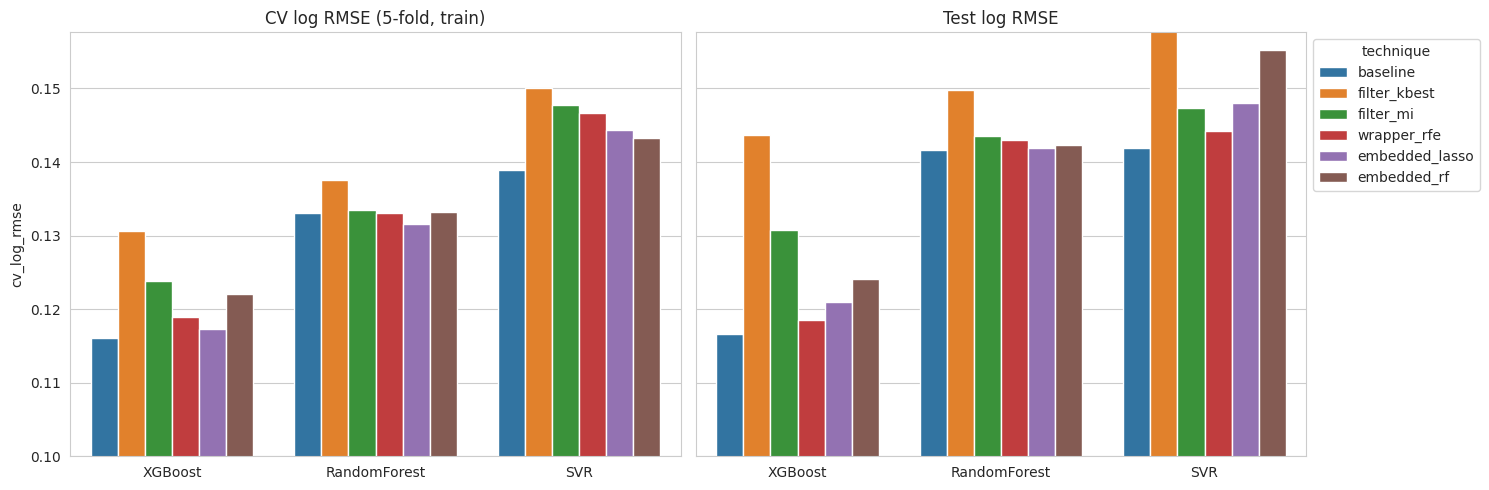

In [6]:
order = ['baseline'] + TECHNIQUES
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, metric, title in zip(axes, ['cv_log_rmse','test_log_rmse'],
                             ['CV log RMSE (5-fold, train)','Test log RMSE']):
    sns.barplot(data=all_results, x='model', y=metric, hue='technique', hue_order=order, ax=ax)
    ax.set_title(title); ax.set_xlabel(''); ax.set_ylim(0.10, None)
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1), title='technique')
axes[0].legend_.remove()
plt.tight_layout(); plt.savefig(FIG_DIR / 'rmse_by_technique.png', dpi=150); plt.show()

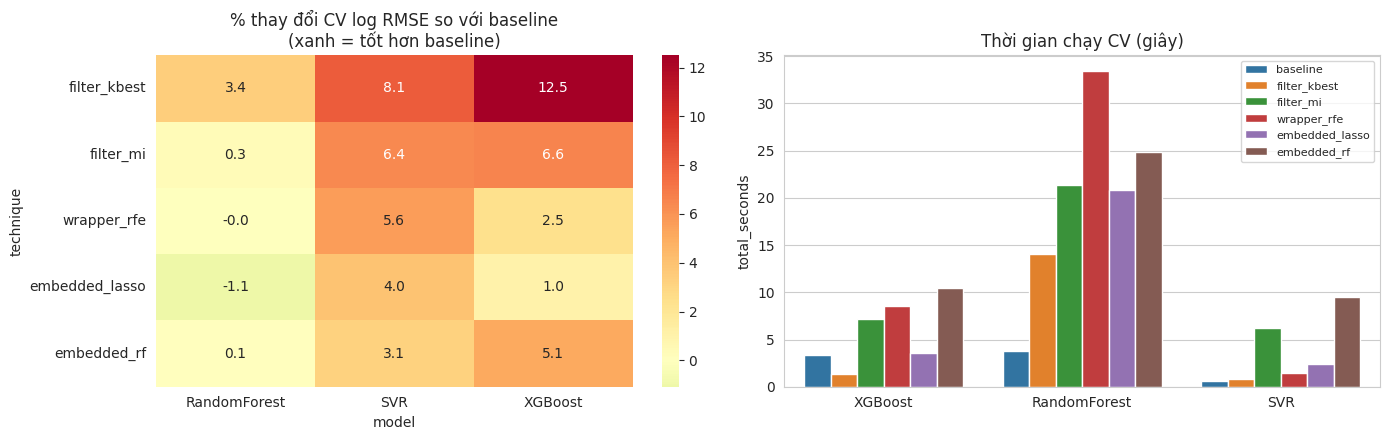

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(delta.drop('baseline'), annot=True, fmt='.1f', cmap='RdYlGn_r', center=0, ax=axes[0])
axes[0].set_title('% thay đổi CV log RMSE so với baseline\n(xanh = tốt hơn baseline)')
tmp = all_results.copy(); tmp['total_seconds'] = tmp['cv_seconds']
sns.barplot(data=tmp, x='model', y='total_seconds', hue='technique', hue_order=order, ax=axes[1])
axes[1].set_title('Thời gian chạy CV (giây)'); axes[1].set_xlabel('')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / 'delta_and_time.png', dpi=150); plt.show()

## 5. Ảnh hưởng của số feature `k` (Filter – F-test)
Quét `k` và chỉ dùng **CV trên train** (không đụng test) để xem số feature hợp lý.

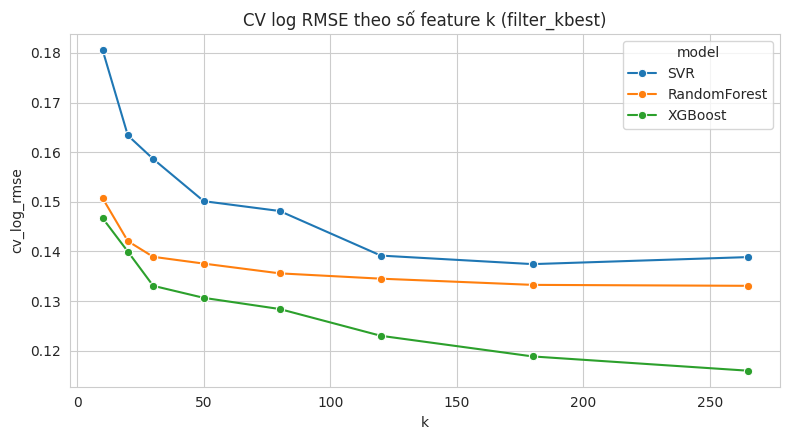

model,RandomForest,SVR,XGBoost
k,,,
10,0.1507,0.1806,0.1467
20,0.1421,0.1634,0.1400
30,0.1389,0.1586,0.1331
50,0.1376,0.1501,0.1307
80,0.1356,0.1481,0.1284
120,0.1345,0.1392,0.1230
180,0.1333,0.1374,0.1188
265,0.1331,0.1389,0.1160


In [8]:
ks = [10, 20, 30, 50, 80, 120, 180, 265]
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
sweep = []
for name, model in make_models().items():
    for k in ks:
        pipe = make_pipeline('filter_kbest', name, model, k=k)
        score = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error').mean()
        sweep.append({'model': name, 'k': k, 'cv_log_rmse': score})
sweep = pd.DataFrame(sweep)
plt.figure(figsize=(8, 4.5))
sns.lineplot(data=sweep, x='k', y='cv_log_rmse', hue='model', marker='o')
plt.title('CV log RMSE theo số feature k (filter_kbest)'); plt.tight_layout()
plt.savefig(FIG_DIR / 'k_sweep_filter.png', dpi=150); plt.show()
sweep.pivot(index='k', columns='model', values='cv_log_rmse').round(4)

## 6. Feature nào được chọn nhiều nhất?
Fit từng bộ chọn trên toàn bộ train (mô hình XGBoost làm ngữ cảnh cho RFE) và đếm số kỹ thuật cùng chọn mỗi feature.

In [9]:
support = pd.DataFrame({t: fitted[(t, 'XGBoost')].named_steps['selector'].get_support()
                        for t in TECHNIQUES}, index=feature_names)
support['n_techniques'] = support.sum(axis=1)
top = support.sort_values('n_techniques', ascending=False)
print('Số feature được chọn bởi mỗi kỹ thuật:'); print(support[TECHNIQUES].sum().to_string())
print('\nFeature được chọn bởi CẢ', len(TECHNIQUES), 'kỹ thuật:', int((support.n_techniques == len(TECHNIQUES)).sum()))
top.head(20)

Số feature được chọn bởi mỗi kỹ thuật:
filter_kbest      50
filter_mi         50
wrapper_rfe       50
embedded_lasso    93
embedded_rf       50

Feature được chọn bởi CẢ 5 kỹ thuật: 18


,filter_kbest,filter_mi,wrapper_rfe,embedded_lasso,embedded_rf,n_techniques
LotArea,True,True,True,True,True,5
ExterQual,True,True,True,True,True,5
CentralAir_N,True,True,True,True,True,5
GarageType_Detchd,True,True,True,True,True,5
HouseAge,True,True,True,True,True,5
RemodAge,True,True,True,True,True,5
GarageArea,True,True,True,True,True,5
TotalBath,True,True,True,True,True,5
GarageCars,True,True,True,True,True,5
TotalSF,True,True,True,True,True,5


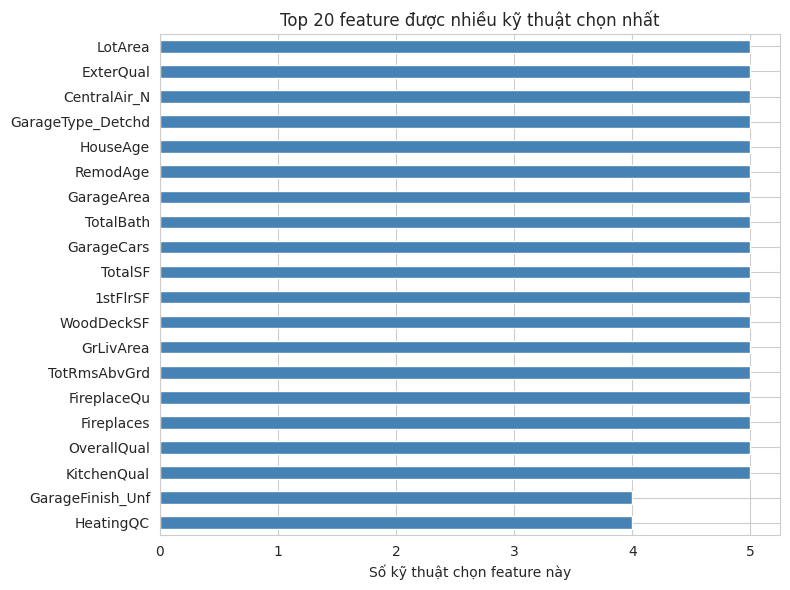

In [10]:
support.astype(int).to_csv(DATA_DIR / 'selected_features_xgboost.csv')
plt.figure(figsize=(8, 6))
top20 = top.head(20)['n_techniques'][::-1]
top20.plot(kind='barh', color='steelblue'); plt.xlabel('Số kỹ thuật chọn feature này')
plt.title('Top 20 feature được nhiều kỹ thuật chọn nhất'); plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_agreement.png', dpi=150); plt.show()

## 7. Chọn kết quả tốt nhất (chỉ dựa vào CV)

In [11]:
best_per_model = fs_results.loc[fs_results.groupby('model')['cv_log_rmse'].idxmin(),
                                ['model','technique','n_features','cv_log_rmse','test_log_rmse','test_original_rmse','test_original_r2']]
best_overall = all_results.sort_values('cv_log_rmse').iloc[0]
print('Tốt nhất cho từng mô hình (trong các kỹ thuật FS):'); display(best_per_model.round(4))
print(f"Tốt nhất toàn bộ (kể cả baseline): {best_overall['technique']} + {best_overall['model']} "
      f"| CV logRMSE={best_overall['cv_log_rmse']:.4f} | test logRMSE={best_overall['test_log_rmse']:.4f} "
      f"| {int(best_overall['n_features'])} feature")

Tốt nhất cho từng mô hình (trong các kỹ thuật FS):


,model,technique,n_features,cv_log_rmse,test_log_rmse,test_original_rmse,test_original_r2
10,RandomForest,embedded_lasso,93,0.1316,0.1419,22949.9843,0.9046
12,SVR,embedded_rf,50,0.1432,0.1552,24178.6076,0.8942
11,XGBoost,embedded_lasso,93,0.1173,0.1210,19770.8113,0.9292


Tốt nhất toàn bộ (kể cả baseline): baseline + XGBoost | CV logRMSE=0.1161 | test logRMSE=0.1167 | 265 feature


## 8. Nhận xét và kết luận

**Kết quả chính (CV log RMSE trên train, thấp hơn = tốt hơn)**
- **XGBoost** (baseline 265 feature: 0.1161): `embedded_lasso` 0.1173 (93 feature), `wrapper_rfe` 0.1190 (50 feature), `embedded_rf` 0.1221, `filter_mi` 0.1238, `filter_kbest` 0.1307. Không kỹ thuật nào vượt baseline, nhưng chỉ cần 50–93 feature (giảm 65–80%) mà sai số chỉ tăng 1–2.5%. Trên tập test, `wrapper_rfe` đạt 0.1185 (baseline 0.1167).
- **RandomForest** (baseline 0.1330): gần như không đổi với mọi kỹ thuật; `embedded_lasso` nhỉnh hơn một chút (0.1316). RandomForest vốn chịu được feature dư thừa nên ít được lợi từ việc chọn lọc.
- **SVR** (baseline 0.1389): mọi kỹ thuật ở k=50 đều kém baseline (0.1432–0.1501). SVR (kernel RBF) nhạy với số chiều và cần nhiều thông tin; phần quét `k` cho thấy sai số giảm khi tăng k và tốt nhất quanh k≈180 (0.1374).

**So sánh các nhóm kỹ thuật**
- **Filter** nhanh nhất và độc lập với mô hình, nhưng yếu nhất: F-test chỉ đo tương quan tuyến tính từng biến, bỏ qua tương tác và dư thừa giữa các feature. Mutual Information tốt hơn F-test rõ rệt với XGBoost (0.1238 so với 0.1307) vì bắt được quan hệ phi tuyến.
- **Wrapper (RFE)** cho kết quả tốt nhất với XGBoost ở đúng 50 feature, vì chọn feature dựa trên chính mô hình, nhưng tốn thời gian nhất (RandomForest: ~33 giây CV so với ~4 giây baseline).
- **Embedded** cân bằng tốt giữa chất lượng và chi phí. `embedded_lasso` tự quyết định số feature (93) và là kỹ thuật ổn định nhất trên cả 3 mô hình; `embedded_rf` tốt nhất cho SVR.
- Có 18 feature được cả 5 kỹ thuật cùng chọn, chủ yếu là diện tích (`TotalSF`, `GrLivArea`, `1stFlrSF`, `GarageArea`), chất lượng (`OverallQual`, `ExterQual`, `KitchenQual`) và tuổi nhà (`HouseAge`, `RemodAge`), phù hợp với kết quả EDA ở Lab03.

**Kết luận:** với bộ dữ liệu này, Feature Selection không cải thiện độ chính xác so với dùng đủ 265 feature, nhưng giúp thu gọn mô hình đáng kể mà gần như không mất độ chính xác (đặc biệt `embedded_lasso` và `wrapper_rfe` với XGBoost). Mô hình tốt nhất theo CV vẫn là XGBoost baseline; nếu ưu tiên mô hình gọn, chọn XGBoost + `embedded_lasso`.

**Hạn chế**
- Chênh lệch giữa các kỹ thuật tốt nhất khá nhỏ (~0.001–0.003), có thể nằm trong nhiễu của CV và của một lần chia train/test duy nhất.
- `k=50` cố định, chưa tuning siêu tham số (theo đúng quy ước: so sánh công bằng trước, tuning sau).
- Bước chuẩn hoá và log-transform trong `01_preprocessing` được fit trên toàn bộ train trước khi CV, nên có rò rỉ nhẹ về phân phối; riêng bước chọn feature thì đã nằm trong từng fold.
- Tập test chỉ dùng để báo cáo; việc xếp hạng dựa hoàn toàn vào CV.